## N23
Implement the gradient descent algorithm with fixed step size.


In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt

In [2]:
def compute_gradient_direction(grad_func, current_point):
    gradient = grad_func(current_point)
    return -gradient

def update_point(current_point, direction, step_size):
    return current_point + step_size * direction

In [3]:
def gradient_descent(func, grad_func, initial_point, step_size=0.1, max_iter=1000000, tol=1e-6):
    point = initial_point.copy()
    history = [func(point)]
    
    for i in range(max_iter):
        # Вычисляем направление движения
        direction = compute_gradient_direction(grad_func, point)
        
        # Вычисляем новую точку
        new_point = update_point(point, direction, step_size)
        
        # Проверяем критерий остановки
        if np.linalg.norm(new_point - point) < tol:
            break
            
        point = new_point
        history.append(func(point))
        
        # Дополнительный критерий остановки
        if len(history) > 1 and abs(history[-1] - history[-2]) < tol:
            break
    
    return point, history

In [4]:
# Пример 1: Квадратичная функция
def quadratic_func(x):
    return x[0]**2 + 2*x[1]**2

def quadratic_grad(x):
    return np.array([2*x[0], 4*x[1]])


start_point = np.array([2.0, 3.0])
result, values_history = gradient_descent(
    quadratic_func, 
    quadratic_grad, 
    start_point, 
    step_size=0.1
)
print(f"Initial point: {start_point}")
print(f"Result: {result}")
print(f"Function value: {quadratic_func(result):.6f}")
print(f"Interations: {len(values_history)}")


Initial point: [2. 3.]
Result: [1.2676506e-03 1.4325590e-07]
Function value: 0.000002
Interations: 34


## N25
Generate 30 random symmetric positive definite matrices A of sizes 10 × 10 to 500 ×
500 (generate random matrices B and form A = BTB to get a symmetric matrix that
is very likely positive definite) and a random vector b of the same size. Apply your
algorithm from Exercise 23 to the function q(x) = x
TAx−b
T x from a random starting
point. Calculate the minimizer and test the convergence speed of the algorithm.
Choose the step size optimally.

In [5]:
def generate_random_spd_problem(n, seed=None):
    if seed is not None:
        np.random.seed(seed)
    # Генерация случайной матрицы B
    B = np.random.randn(n, n)
    # Формирование SPD матрицы: A = B^T B + εI для гарантии положительной определённости
    A = B.T @ B + 0.01 * np.eye(n)
    # Генерация случайного вектора b
    b = np.random.randn(n)
    # Случайная начальная точка
    x0 = np.random.randn(n)
    return A, b, x0

In [6]:
def create_quadratic_functions(A, b):
    def q(x):
        return x.T @ A @ x - b.T @ x
    
    def grad_q(x):
        return 2 * A @ x - b
    
    return q, grad_q

In [7]:
def compute_optimal_step_size(A, method='exact'):
    if method == 'exact':
        # Точное вычисление через собственные значения
        eigenvalues = np.linalg.eigvalsh(A)
        λ_min, λ_max = eigenvalues[0], eigenvalues[-1]
    elif method == 'estimate':
        # Оценка через нормы (для больших матриц)
        λ_max = np.linalg.norm(A, 2)  # Спектральная норма
        # Для λ_min используем оценку через след и размерность
        λ_min = np.trace(A) / A.shape[0] / 10  # Оценочное значение
    
    η_opt = 1 / (λ_min + λ_max)
    return η_opt, λ_min, λ_max

In [9]:
def run_experiment(
    min_size=10,
    max_size=500,
    num_matrices=30,
    max_iter=100000,
    tol=1e-6
):
    # Размеры матриц
    sizes = np.logspace(
        np.log10(min_size), 
        np.log10(max_size), 
        num_matrices, 
        dtype=int
    )
    
    results = []
    
    for i, n in enumerate(sizes):
        print(f"Тест {i+1}/{num_matrices}: размер матрицы = {n}")
        
        # Генерация задачи
        A, b, x0 = generate_random_spd_problem(n, seed=i)
        
        # Создание функций
        q, grad_q = create_quadratic_functions(A, b)
        
        # Вычисление оптимального шага
        η_opt, λ_min, λ_max = compute_optimal_step_size(A)
        κ = λ_max / λ_min if λ_min > 0 else float('inf')
        
        # Точное решение
        x_exact = 0.5 * np.linalg.solve(A, b)
        
        # Запуск градиентного спуска (используем вашу функцию)
        start_time = time.time()
        x_opt, f_history = gradient_descent(
            q, grad_q, x0, 
            step_size=η_opt,
            max_iter=max_iter,
            tol=tol
        )
        elapsed_time = time.time() - start_time
        
        # Вычисление ошибок и других метрик
        initial_error = np.linalg.norm(x0 - x_exact)
        final_error = np.linalg.norm(x_opt - x_exact)
        grad_norm_final = np.linalg.norm(grad_q(x_opt))
        
        initial_value = q(x0)
        final_value = q(x_opt)
        exact_value = q(x_exact)
        
        # Оцениваем практическую скорость сходимости по истории значений функции
        practical_rate = None
        if len(f_history) > 10:
            f_errors = np.array(f_history) - exact_value
            mask = f_errors > 0
            if np.sum(mask) > 5:
                log_errors = np.log(f_errors[mask])
                idx = np.arange(len(log_errors))
                coeff = np.polyfit(idx, log_errors, 1)
                practical_rate = np.exp(coeff[0])
        
        # Сохранение результатов
        result = {
            'size': n,
            'η_opt': η_opt,
            'λ_min': λ_min,
            'λ_max': λ_max,
            'condition_number': κ,
            'iterations': len(f_history) - 1,  # -1 потому что начальная точка тоже в истории
            'time': elapsed_time,
            'initial_error': initial_error,
            'final_error': final_error,
            'grad_norm_final': grad_norm_final,
            'initial_value': initial_value,
            'final_value': final_value,
            'exact_value': exact_value,
            'theoretical_rate': (κ - 1) / (κ + 1),
            'practical_rate': practical_rate,
            'f_history': f_history
        }
        
        results.append(result)
        
        print(f"Iterations: {result['iterations']}, Time: {elapsed_time:.3f} с")
        print(f"K: {κ:.2f}")
        print(f"Optimal rate: {η_opt:.6f}")
        print(f"error: {initial_error:.3e} -> {final_error:.3e}")
        print(f"Gradient norm: {grad_norm_final:.3e}")
        print()
    
    return results

In [12]:
NUM_MATRICES = 30
MIN_SIZE = 10
MAX_SIZE = 500
MAX_ITER = 1000000
TOL = 1e-6
    # Запуск эксперимента
results = run_experiment(
    min_size=MIN_SIZE,
    max_size=MAX_SIZE,
    num_matrices=NUM_MATRICES,
    max_iter=MAX_ITER,
    tol=TOL
    )
    
    # Статистика
print("\nExperiment statistics:")
iterations = [r['iterations'] for r in results]
times = [r['time'] for r in results]
condition_numbers = [r['condition_number'] for r in results]
    


Тест 1/30: размер матрицы = 10
Iterations: 7184, Time: 0.238 с
K: 2855.23
Optimal rate: 0.033196
error: 1.076e+01 -> 6.577e-02
Gradient norm: 2.835e-01

Тест 2/30: размер матрицы = 11
Iterations: 2054, Time: 0.065 с
K: 712.87
Optimal rate: 0.033096
error: 7.920e+00 -> 1.830e-02
Gradient norm: 1.405e-01

Тест 3/30: размер матрицы = 13
Iterations: 1628, Time: 0.050 с
K: 469.53
Optimal rate: 0.018596
error: 1.020e+01 -> 9.544e-03
Gradient norm: 1.513e-01

Тест 4/30: размер матрицы = 14
Iterations: 1107, Time: 0.032 с
K: 315.49
Optimal rate: 0.024728
error: 5.984e+00 -> 4.339e-03
Gradient norm: 1.104e-01

Тест 5/30: размер матрицы = 17
Iterations: 13791, Time: 0.379 с
K: 4791.07
Optimal rate: 0.020545
error: 6.626e+01 -> 2.087e-01
Gradient norm: 3.832e-01

Тест 6/30: размер матрицы = 19
Iterations: 5950, Time: 0.152 с
K: 2260.84
Optimal rate: 0.016394
error: 1.302e+01 -> 6.381e-02
Gradient norm: 3.331e-01

Тест 7/30: размер матрицы = 22
Iterations: 9096, Time: 0.229 с
K: 3547.99
Optimal ra

In [13]:
print(f"Average iterations: {np.mean(iterations):.1f}")
print(f"Median iterations: {np.median(iterations):.1f}")
print(f"Min inter: {np.min(iterations)}")
print(f"Max iter: {np.max(iterations)}")
print(f"Average time: {np.mean(times):.3f} с")
print(f"Average condition num: {np.mean(condition_numbers):.2f}")
print(f"Max condition num: {np.max(condition_numbers):.2f}")

Average iterations: 89567.6
Median iterations: 48334.5
Min inter: 1107
Max iter: 422781
Average time: 36.848 с
Average condition num: 37005.56
Max condition num: 148697.12


In [14]:
theoretical_rates = [r['theoretical_rate'] for r in results]
practical_rates = [r['practical_rate'] for r in results if r['practical_rate'] is not None]

avg_theoretical = np.mean(theoretical_rates) if theoretical_rates else 0
avg_practical = np.mean(practical_rates) if practical_rates else 0

print(f"Average theoretical convergence rate: {avg_theoretical:.6f}")
print(f"Average practical convergence rate: {avg_practical:.6f}")

Average theoretical convergence rate: 0.999315
Average practical convergence rate: 0.998625


C:\Users\andre\AppData\Local\Temp\ipykernel_12136\2539402822.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


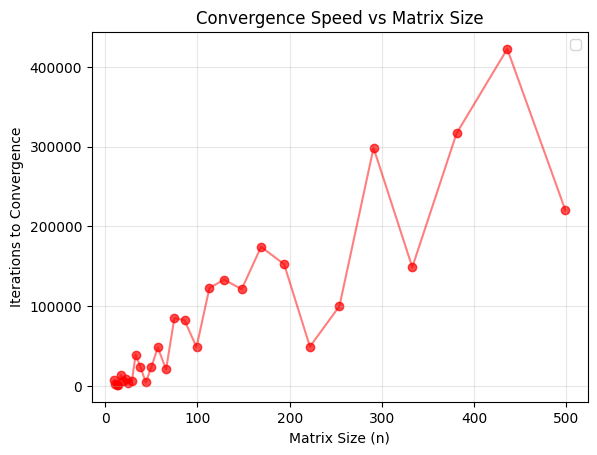

In [16]:
# Plot 2: Iterations needed vs matrix size
#plt.subplot(1, 2, 2)
sizes = [res['size'] for res in results]
iterations_needed = [res['iterations'] for res in results]
plt.scatter(sizes, iterations_needed,color = 'r', alpha=0.7)
plt.plot(sizes, iterations_needed, 'r-', alpha=0.5)

plt.xlabel('Matrix Size (n)')
plt.ylabel('Iterations to Convergence')
plt.title('Convergence Speed vs Matrix Size')
plt.legend()
plt.grid(True, alpha=0.3)

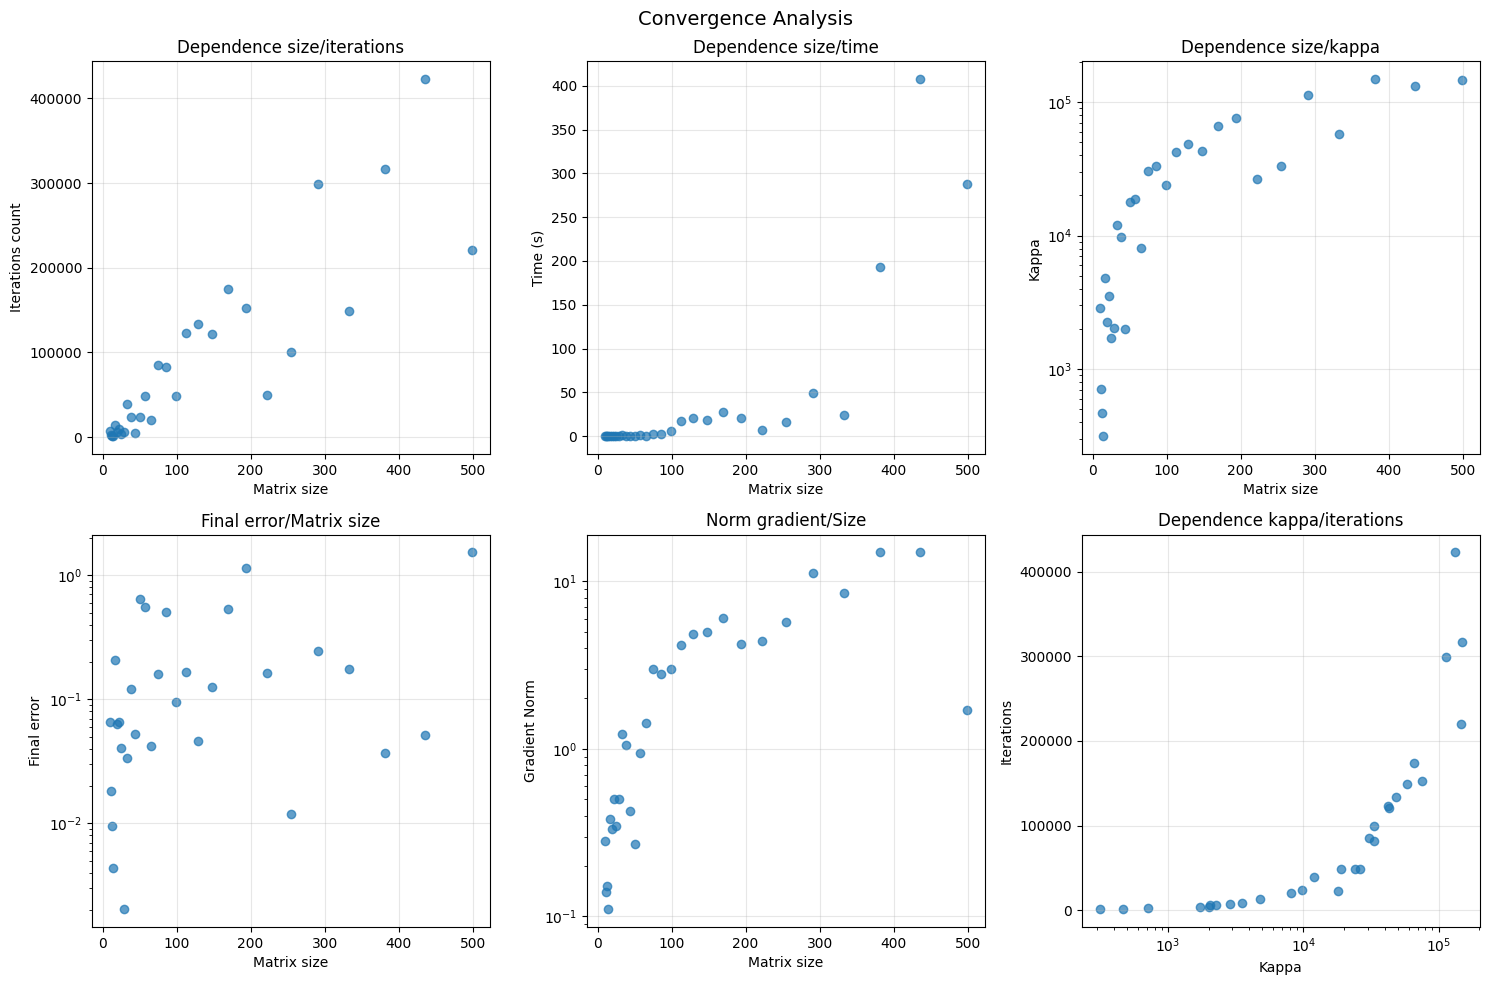

In [17]:
def plot_results(results):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('Convergence Analysis', fontsize=14)
    
    sizes = [r['size'] for r in results]
    iterations = [r['iterations'] for r in results]
    times = [r['time'] for r in results]
    condition_numbers = [r['condition_number'] for r in results]
    final_errors = [r['final_error'] for r in results]
    grad_norms = [r['grad_norm_final'] for r in results]
    
    ax = axes[0, 0]
    ax.scatter(sizes, iterations, alpha=0.7)
    ax.set_xlabel('Matrix size')
    ax.set_ylabel('Iterations count')
    ax.set_title('Dependence size/iterations')
    ax.grid(True, alpha=0.3)
    
    ax = axes[0, 1]
    ax.scatter(sizes, times, alpha=0.7)
    ax.set_xlabel('Matrix size')
    ax.set_ylabel('Time (s)')
    ax.set_title('Dependence size/time')
    ax.grid(True, alpha=0.3)
    
    ax = axes[0, 2]
    ax.scatter(sizes, condition_numbers, alpha=0.7)
    ax.set_xlabel('Matrix size')
    ax.set_ylabel('Kappa')
    ax.set_title('Dependence size/kappa')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
  
    ax = axes[1, 0]
    ax.scatter(sizes, final_errors, alpha=0.7)
    ax.set_xlabel('Matrix size')
    ax.set_ylabel('Final error')
    ax.set_title('Final error/Matrix size')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    
    ax = axes[1, 1]
    ax.scatter(sizes, grad_norms, alpha=0.7)
    ax.set_xlabel('Matrix size')
    ax.set_ylabel('Gradient Norm')
    ax.set_title('Norm gradient/Size')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    
    ax = axes[1, 2]
    ax.scatter(condition_numbers, iterations, alpha=0.7)
    ax.set_xlabel('Kappa')
    ax.set_ylabel('Iterations')
    ax.set_title('Dependence kappa/iterations')
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_results(results)

## N26
Repeat exercise 25 for the function n(x) = sqrt(x^TAx + b^Tx). Compare the results.

In [31]:
def create_function(A, b, epsilon=1e-8):
    def n_func(x):
        # Сумма под корнем
        under_sqrt = x.T @ A @ x + b.T @ x
        # Гарантируем, что под корнем неотрицательное значение
        # return np.sqrt(max(under_sqrt, 0) + epsilon)
        return np.sqrt(under_sqrt + epsilon)
    
    def grad_n_func(x):
        # Градиент: (2Ax + b) / (2 * sqrt(x^T A x + b^T x))
        under_sqrt = x.T @ A @ x + b.T @ x
        sqrt_term = np.sqrt(max(under_sqrt, 0) + epsilon)
        
        if sqrt_term < 1e-12:  # Избегаем деления на ноль
            return np.zeros_like(x)
        
        return (2 * A @ x + b) / (2 * sqrt_term)
    
    return n_func, grad_n_func

In [32]:
def run_experiment_n(min_size=10, max_size=500, num_matrices=30, max_iter=1000000,tol=1e-6):
    sizes = np.logspace(
        np.log10(min_size), 
        np.log10(max_size), 
        num_matrices, 
        dtype=int
    )
    results = []
    for i, n in enumerate(sizes):
        print(f"Тест {i+1}/{num_matrices}: размер матрицы = {n}")
        
        # Генерация задачи
        A, b, x0 = generate_random_spd_problem(n, seed=i)
        
        # Используем новые функции для n(x)
        n_func, grad_n_func = create_function(A, b)
        
        eigenvalues = np.linalg.eigvalsh(A)
        λ_min, λ_max = eigenvalues[0], eigenvalues[-1]
        κ = λ_max / λ_min if λ_min > 0 else float('inf')
        
        # Для n(x) эмпирический подбор шага
        # Базовый шаг: 1 / (||A||_2 + ||b||_2)
        norm_A = np.linalg.norm(A, 2)
        norm_b = np.linalg.norm(b, 2)
        η_empirical = 0.1 / (norm_A + norm_b)  # Меньший коэффициент для безопасности
        
        # Пробуем несколько шагов
        η_candidates = [η_empirical * 0.1, η_empirical * 0.5, η_empirical, 
                       η_empirical * 2, η_empirical * 5]
        
        best_η = η_empirical
        best_iterations = max_iter
        
        # Быстрый подбор оптимального шага
        for η_test in η_candidates:
            x_test, f_history_test, _ = gradient_descent(
                n_func, grad_n_func, x0,
                step_size=η_test,
                max_iter=200,  # Короткий прогон для теста
                tol=tol
            )
            # Проверяем, что функция не расходится
            if len(f_history_test) < 50:  # Слишком быстро сошлось - возможно, шаг слишком большой
                continue
            # Считаем улучшение за последние 10 итераций
            if len(f_history_test) > 20:
                improvement = abs(f_history_test[-1] - f_history_test[-10]) / abs(f_history_test[0] - f_history_test[-1])
                if improvement < 0.1:  # Хорошее улучшение
                    iterations_test = len(f_history_test) - 1
                    if iterations_test < best_iterations:
                        best_iterations = iterations_test
                        best_η = η_test
        
        print(f"Select the step size: {best_η:.6e}")
        
        # Запуск градиентного спуска с выбранным шагом
        start_time = time.time()
        x_opt, f_history, x_history = gradient_descent(
            n_func, grad_n_func, x0,
            step_size=best_η,
            max_iter=max_iter,
            tol=tol
        )
        elapsed_time = time.time() - start_time
        
        # Вычисление метрик
        grad_norm_final = np.linalg.norm(grad_n_func(x_opt))
        initial_value = n_func(x0)
        final_value = n_func(x_opt)
        
        # Оцениваем скорость сходимости
        practical_rate = None
        if len(f_history) > 20:
            # Берем последние 50% значений для оценки скорости
            n_points = len(f_history)
            start_idx = int(0.5 * n_points)
            if start_idx < n_points - 5:
                recent_vals = f_history[start_idx:]
                if len(recent_vals) >= 5:
                    # Проверяем монотонное убывание
                    is_monotonic = all(recent_vals[i] <= recent_vals[i-1] for i in range(1, len(recent_vals)))
                    if is_monotonic:
                        # Линейная регрессия в логарифмической шкале
                        log_vals = np.log(np.array(recent_vals) - final_value + 1e-12)
                        idx = np.arange(len(log_vals))
                        coeff = np.polyfit(idx, log_vals, 1)
                        practical_rate = np.exp(coeff[0])
        
        result = {
            'size': n,
            'η': best_η,
            'λ_min': λ_min,
            'λ_max': λ_max,
            'condition_number': κ,
            'iterations': len(f_history) - 1,
            'time': elapsed_time,
            'grad_norm_final': grad_norm_final,
            'initial_value': initial_value,
            'final_value': final_value,
            'practical_rate': practical_rate,
            'f_history': f_history
        }
        
        results.append(result)
        if (i+1 > 45):
            print(f"  Iterations: {result['iterations']}, Time: {elapsed_time:.3f} с")
            print(f"K: {κ:.2f}")
            print(f"Gradient norm: {grad_norm_final:.3e}")
            print(f"Function value: {initial_value:.3e} → {final_value:.3e}")
        
        # Проверка на отрицательное значение под корнем
        under_sqrt_final = x_opt.T @ A @ x_opt + b.T @ x_opt
        if under_sqrt_final < 0:
            print(f"  ВНИМАНИЕ: отрицательное значение под корнем: {under_sqrt_final:.3e}")
    
    return results

In [33]:
NUM_MATRICES = 30
MIN_SIZE = 10
MAX_SIZE = 500
MAX_ITER = 1000000
TOL = 1e-6
    # Запуск эксперимента
results_26 = run_experiment(
    min_size=MIN_SIZE,
    max_size=MAX_SIZE,
    num_matrices=NUM_MATRICES,
    max_iter=MAX_ITER,
    tol=TOL
    )
    
    # Статистика
print("\nExperiment statistics:")
iterations = [r['iterations'] for r in results_26]
times = [r['time'] for r in results_26]
condition_numbers = [r['condition_number'] for r in results_26]
    


Тест 1/30: размер матрицы = 10
Iterations: 7184, Time: 0.247 с
K: 2855.23
Optimal rate: 0.033196
error: 1.076e+01 -> 6.577e-02
Gradient norm: 2.835e-01

Тест 2/30: размер матрицы = 11
Iterations: 2054, Time: 0.065 с
K: 712.87
Optimal rate: 0.033096
error: 7.920e+00 -> 1.830e-02
Gradient norm: 1.405e-01

Тест 3/30: размер матрицы = 13
Iterations: 1628, Time: 0.043 с
K: 469.53
Optimal rate: 0.018596
error: 1.020e+01 -> 9.544e-03
Gradient norm: 1.513e-01

Тест 4/30: размер матрицы = 14
Iterations: 1107, Time: 0.028 с
K: 315.49
Optimal rate: 0.024728
error: 5.984e+00 -> 4.339e-03
Gradient norm: 1.104e-01

Тест 5/30: размер матрицы = 17
Iterations: 13791, Time: 0.467 с
K: 4791.07
Optimal rate: 0.020545
error: 6.626e+01 -> 2.087e-01
Gradient norm: 3.832e-01

Тест 6/30: размер матрицы = 19
Iterations: 5950, Time: 0.182 с
K: 2260.84
Optimal rate: 0.016394
error: 1.302e+01 -> 6.381e-02
Gradient norm: 3.331e-01

Тест 7/30: размер матрицы = 22
Iterations: 9096, Time: 0.249 с
K: 3547.99
Optimal ra

In [34]:
print(f"Average iterations: {np.mean(iterations):.1f}")
print(f"Median iterations: {np.median(iterations):.1f}")
print(f"Min inter: {np.min(iterations)}")
print(f"Max iter: {np.max(iterations)}")
print(f"Average time: {np.mean(times):.3f} с")
print(f"Average condition num: {np.mean(condition_numbers):.2f}")
print(f"Max condition num: {np.max(condition_numbers):.2f}")

Average iterations: 89567.6
Median iterations: 48334.5
Min inter: 1107
Max iter: 422781
Average time: 36.448 с
Average condition num: 37005.56
Max condition num: 148697.12


In [35]:
theoretical_rates = [r['theoretical_rate'] for r in results_26]
practical_rates = [r['practical_rate'] for r in results_26 if r['practical_rate'] is not None]

avg_theoretical = np.mean(theoretical_rates) if theoretical_rates else 0
avg_practical = np.mean(practical_rates) if practical_rates else 0

print(f"Average theoretical convergence rate: {avg_theoretical:.6f}")
print(f"Average practical convergence rate: {avg_practical:.6f}")

Average theoretical convergence rate: 0.999315
Average practical convergence rate: 0.998625


C:\Users\andre\AppData\Local\Temp\ipykernel_12136\3522938841.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


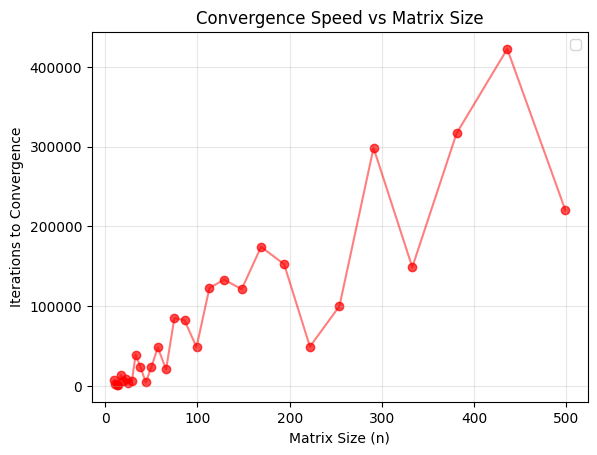

In [36]:
# Plot 2: Iterations needed vs matrix size
#plt.subplot(1, 2, 2)
sizes = [res['size'] for res in results_26]
iterations_needed = [res['iterations'] for res in results_26]
plt.scatter(sizes, iterations_needed,color = 'r', alpha=0.7)
plt.plot(sizes, iterations_needed, 'r-', alpha=0.5)

plt.xlabel('Matrix Size (n)')
plt.ylabel('Iterations to Convergence')
plt.title('Convergence Speed vs Matrix Size')
plt.legend()
plt.grid(True, alpha=0.3)

In [37]:
def plot_comparison_results(results_q, results_n):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('Compare grad descent q(x) and n(x)', fontsize=14)
    
    sizes = [r['size'] for r in results_q]
    iterations_q = [r['iterations'] for r in results_q]
    iterations_n = [r['iterations'] for r in results_n]
    times_q = [r['time'] for r in results_q]
    times_n = [r['time'] for r in results_n]
    condition_numbers = [r['condition_number'] for r in results_q]
    
    ax = axes[0, 0]
    ax.scatter(sizes, iterations_q, alpha=0.7, label='q(x)', color='blue')
    ax.scatter(sizes, iterations_n, alpha=0.7, label='n(x)', color='red')
    ax.set_xlabel('Matrix size')
    ax.set_ylabel('Iterations')
    ax.set_title('Iterations compare')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    ax = axes[0, 1]
    ax.scatter(sizes, times_q, alpha=0.7, label='q(x)', color='blue')
    ax.scatter(sizes, times_n, alpha=0.7, label='n(x)', color='red')
    ax.set_xlabel('Matrix size')
    ax.set_ylabel('Time (s)')
    ax.set_title('Compare time')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    ax = axes[0, 2]
    iteration_ratios = [n/q for n, q in zip(iterations_n, iterations_q)]
    ax.scatter(sizes, iteration_ratios, alpha=0.7, color='green')
    ax.axhline(y=1, color='r', linestyle='--', alpha=0.5)
    ax.set_xlabel('Matrix size')
    ax.set_ylabel('Iterarions proportion n(x)/q(x)')
    ax.set_title('Iterations proportion')
    ax.grid(True, alpha=0.3)
    
    ax = axes[1, 0]
    ax.scatter(condition_numbers, iterations_q, alpha=0.7, color='blue')
    ax.set_xlabel('Kappa')
    ax.set_ylabel('Iterations q(x)')
    ax.set_title('q(x): Iterarions/kappa')
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)
    
    ax = axes[1, 1]
    ax.scatter(condition_numbers, iterations_n, alpha=0.7, color='red')
    ax.set_xlabel('Kappa')
    ax.set_ylabel('Iterations n(x)')
    ax.set_title('n(x): Iterarions/kappa')
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)
    
    # ax = axes[1, 2]
    # η_ratios = [r_n['η']/r_q['η'] for r_n, r_q in zip(results_n, results_q)]
    # ax.scatter(sizes, η_ratios, alpha=0.7, color='purple')
    # ax.axhline(y=1, color='r', linestyle='--', alpha=0.5)
    # ax.set_xlabel('Matrix size')
    # ax.set_ylabel('Proportion steps η_n/η_q')
    # ax.set_title('Compare step sizes')
    # ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # if len(results_q) > 5:
    #     idx = 5  
    #     fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
    #     # Сходимость q(x)
    #     ax = axes[0]
    #     f_history_q = results_q[idx]['f_history']
    #     iterations_q = range(len(f_history_q))
    #     ax.semilogy(iterations_q, f_history_q, 'b-', linewidth=2)
    #     ax.set_xlabel('Итерация')
    #     ax.set_ylabel('Значение q(x)')
    #     ax.set_title(f'Сходимость q(x), размер={results_q[idx]["size"]}')
    #     ax.grid(True, alpha=0.3)
        
    #     # Сходимость n(x)
    #     ax = axes[1]
    #     f_history_n = results_n[idx]['f_history']
    #     iterations_n = range(len(f_history_n))
    #     ax.semilogy(iterations_n, f_history_n, 'r-', linewidth=2)
    #     ax.set_xlabel('Итерация')
    #     ax.set_ylabel('Значение n(x)')
    #     ax.set_title(f'Сходимость n(x), размер={results_n[idx]["size"]}')
    #     ax.grid(True, alpha=0.3)
        
    #     plt.tight_layout()
    #     plt.show()

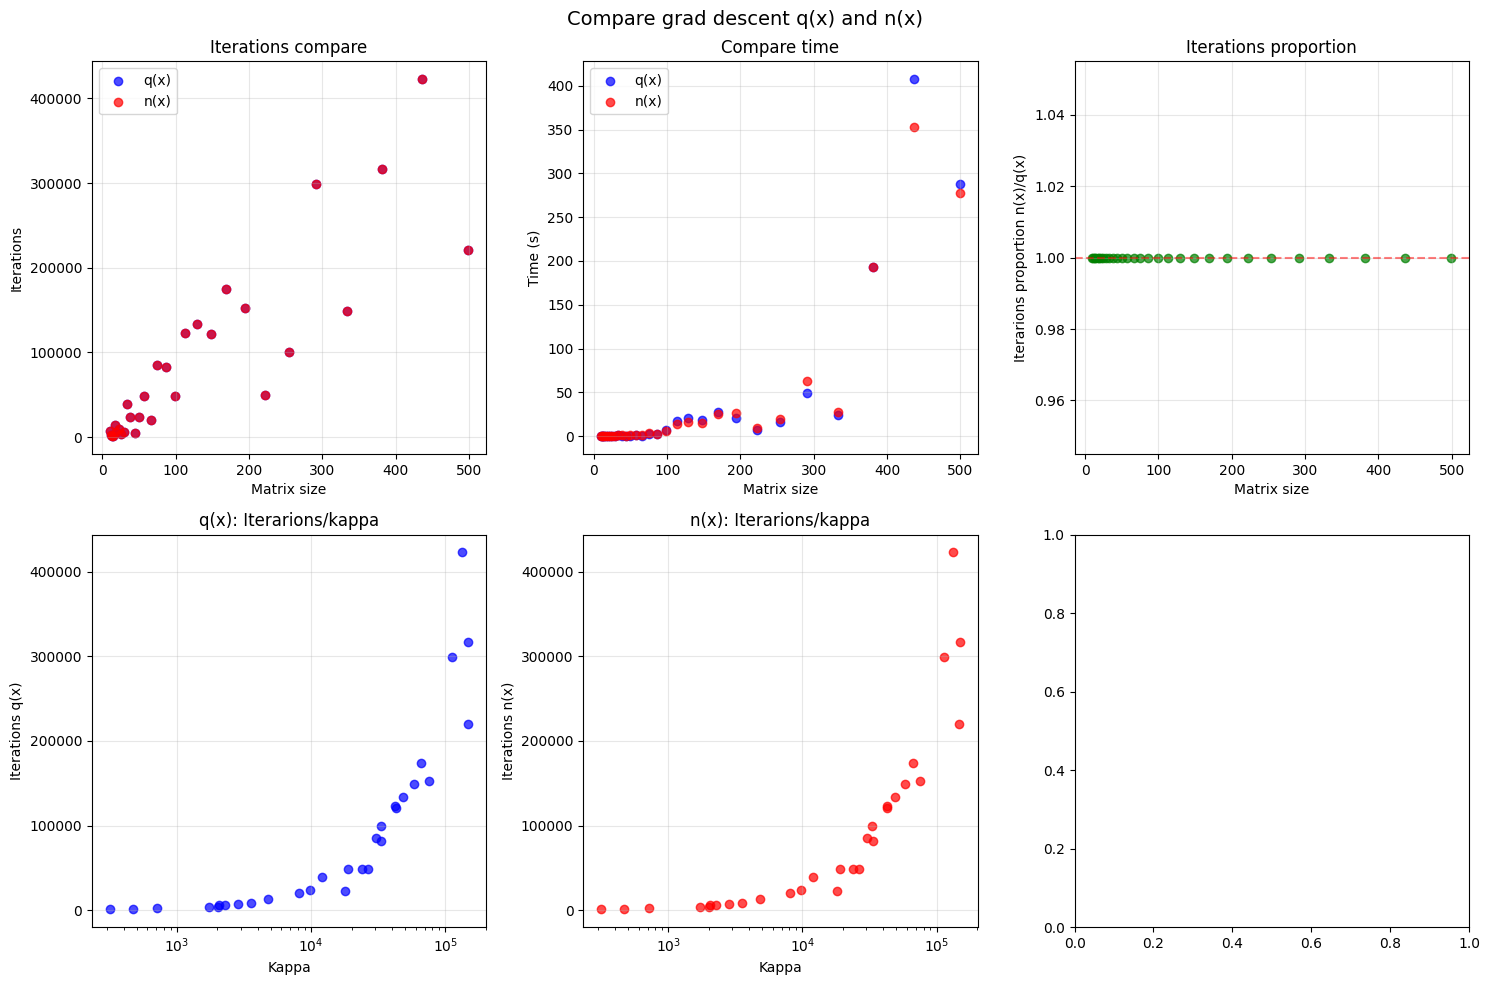

In [25]:
plot_comparison_results(results, results_26)

## N28

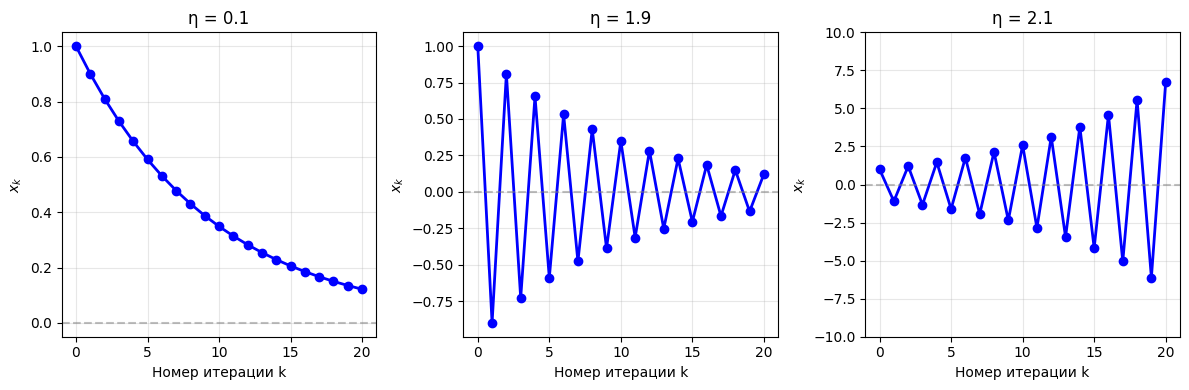

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Начальные параметры
x0 = 1
k_max = 20
etas = [0.1, 1.9, 2.1]

# Создание графиков
plt.figure(figsize=(12, 4))

for i, eta in enumerate(etas, 1):
    plt.subplot(1, 3, i)
    
    # Вычисление последовательности
    k = np.arange(k_max + 1)
    x = x0 * (1 - eta) ** k
    
    # Построение графика
    plt.plot(k, x, 'bo-', linewidth=2, markersize=6)
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    plt.title(f'η = {eta}')
    plt.xlabel('Номер итерации k')
    plt.ylabel('$x_k$')
    plt.grid(True, alpha=0.3)
    
    # Установка пределов для лучшей визуализации
    if eta == 2.1:
        plt.ylim(-10, 10)  # Для расходящегося случая

plt.tight_layout()
plt.show()